In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as mticker
from linearmodels.iv import IV2SLS
import glob

In [2]:
files = glob.glob('../HW4/data/output/data-*.csv')
data = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

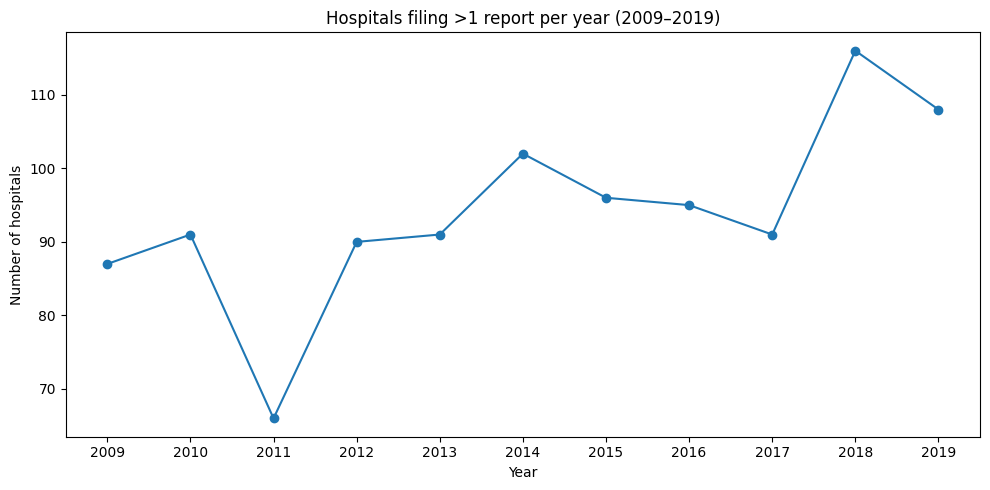

    year  hospitals
0   2009         87
1   2010         91
2   2011         66
3   2012         90
4   2013         91
5   2014        102
6   2015         96
7   2016         95
8   2017         91
9   2018        116
10  2019        108


In [3]:
#Question 1
df = data[data['year'].between(2009, 2019)]

result = (
    df[df['source'] != 'unique reports']
    .groupby('year')['provider_number']
    .nunique()
    .reset_index(name='hospitals')
)

plt.figure(figsize=(10, 5))
plt.plot(result['year'], result['hospitals'], marker='o')
plt.title('Hospitals filing >1 report per year (2009–2019)')
plt.xlabel('Year'); plt.ylabel('Number of hospitals')
plt.xticks(result['year'])
plt.tight_layout(); plt.show()
print(result)

In [4]:
#Question 2

# Unique hospital IDs per year (multiples already combined in source data)
result = (df.groupby('year')['provider_number']
            .nunique()
            .reset_index(name='unique_hospitals'))

print(result)
print("Total unique IDs across 2009-2019:", df['provider_number'].nunique())



    year  unique_hospitals
0   2009              6100
1   2010              6103
2   2011              6097
3   2012              6140
4   2013              6066
5   2014              6064
6   2015              6051
7   2016              6091
8   2017              6083
9   2018              6042
10  2019              6035
Total unique IDs across 2009-2019: 6897


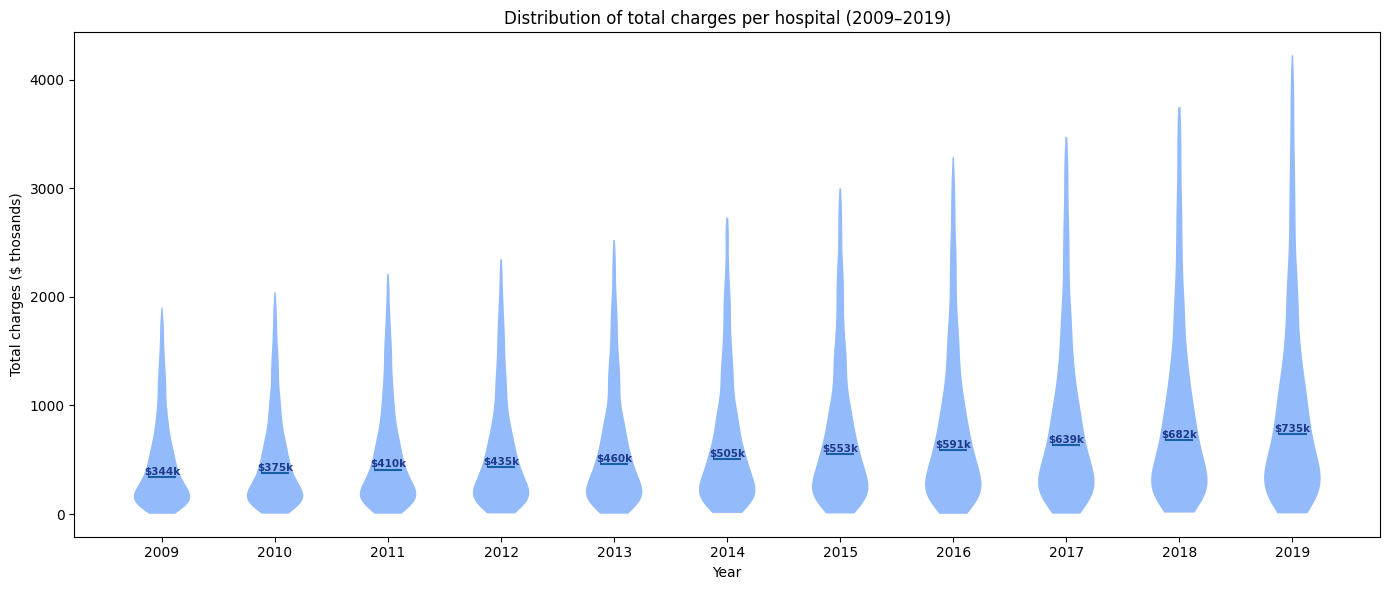

In [15]:
#Question 3 

years = sorted(df['year'].unique())
charges_data = []
for yr in years:
    d = df[df['year']==yr]['tot_charges'].dropna()
    cap = d.quantile(0.95)          # remove top 5% outliers each year
    charges_data.append(d[d <= cap].values / 1e6)

fig, ax = plt.subplots(figsize=(14, 6))
parts = ax.violinplot(charges_data, positions=list(range(len(years))),
                      showmedians=True, showextrema=False)

for i, arr in enumerate(charges_data):
    med = np.median(arr)
    ax.text(i, med + 0.5, f'${med:,.0f}k', ha='center', va='bottom',
            fontsize=7.5, color='#1e3a8a', fontweight='bold')
 
for pc in parts['bodies']:
    pc.set_facecolor('#3b82f6')
    pc.set_alpha(0.55)
parts['cmedians'].set_color('#185FA5')
ax.set_xticks(range(len(years))); ax.set_xticklabels(years)
ax.set_xlabel('Year')
ax.set_ylabel('Total charges ($ thosands)')
ax.set_title('Distribution of total charges per hospital (2009–2019)')
plt.tight_layout()
plt.savefig('q1_charges_violin.png', dpi=150)
plt.show()

/tmp/ipykernel_3474859/783162422.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['discount_factor'] = 1 - df['tot_discounts'] / df['tot_charges']
/tmp/ipykernel_3474859/783162422.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_num']   = (
/tmp/ipykernel_3474859/783162422.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

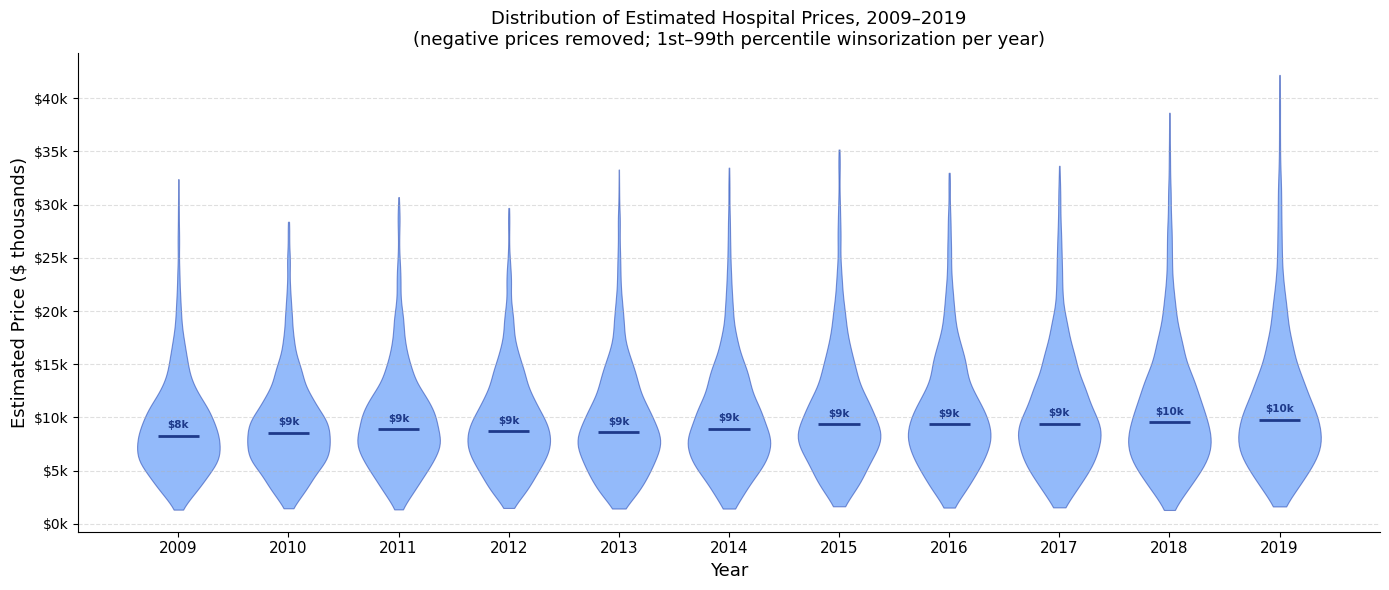

         n  median     mean     p25      p75
year                                        
2009  2736  8276.0   8991.0  5880.0  11121.0
2010  2733  8565.0   9240.0  6116.0  11433.0
2011  2672  8886.0   9574.0  6348.0  11847.0
2012  2716  8696.0   9463.0  6182.0  11880.0
2013  2686  8603.0   9480.0  5972.0  11916.0
2014  2654  8938.0   9859.0  6264.0  12476.0
2015  2655  9332.0  10375.0  6733.0  12908.0
2016  2646  9333.0  10304.0  6565.0  12814.0
2017  2620  9399.0  10424.0  6575.0  13050.0
2018  2617  9555.0  10716.0  6565.0  13520.0
2019  2590  9781.0  11031.0  6759.0  13666.0


In [6]:
#Question 4
df['discount_factor'] = 1 - df['tot_discounts'] / df['tot_charges']
 
df['price_num']   = (
    (df['ip_charges'] + df['icu_charges'] + df['ancillary_charges'])
    * df['discount_factor']
    - df['tot_mcare_payment']
)
df['price_denom'] = df['tot_discharges'] - df['mcare_discharges']
df['price']       = df['price_num'] / df['price_denom']


# remove zero / negative prices
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]                         
 
def remove_outliers(g):
    lo, hi = g['price'].quantile([0.01, 0.99])
    return g[(g['price'] >= lo) & (g['price'] <= hi)]
 
df = df.groupby('year', group_keys=False).apply(remove_outliers)
 
years       = sorted(df['year'].unique())
price_data  = [df.loc[df['year'] == yr, 'price'].values / 1_000
               for yr in years]                    
 
fig, ax = plt.subplots(figsize=(14, 6))
 
parts = ax.violinplot(
    price_data,
    positions=list(range(len(years))),
    showmedians=True,
    showextrema=False,
    widths=0.75,
)
for pc in parts['bodies']:
    pc.set_facecolor('#3b82f6')
    pc.set_alpha(0.55)
    pc.set_edgecolor('#1e40af')
    pc.set_linewidth(0.8)
 
parts['cmedians'].set_color('#1e3a8a')
parts['cmedians'].set_linewidth(2)
 
# Overlay the median value as text
for i, arr in enumerate(price_data):
    med = np.median(arr)
    ax.text(i, med + 0.5, f'${med:,.0f}k', ha='center', va='bottom',
            fontsize=7.5, color='#1e3a8a', fontweight='bold')
 
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, fontsize=11)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Estimated Price ($ thousands)', fontsize=13)
ax.set_title('Distribution of Estimated Hospital Prices, 2009–2019\n'
             '(negative prices removed; 1st–99th percentile winsorization per year)',
             fontsize=13)
 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}k'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns_style = dict(top=False, right=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig('price_violin_2009_2019.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Results table 
summary = (df.groupby('year')['price']
             .agg(n='count', median='median', mean='mean',
                  p25=lambda x: x.quantile(0.25),
                  p75=lambda x: x.quantile(0.75))
             .round(0))
print(summary.to_string())

 year  hrrp_share  vbp_share  any_share  n_hospitals
 2012    0.121336   0.076710   0.142182         6140
 2013    0.342509   0.207186   0.394429         6066
 2014    0.385655   0.231987   0.425721         6064
 2015    0.424558   0.217319   0.446207         6051
 2016    0.433591   0.202758   0.450993         6091
 2017    0.438271   0.215190   0.452902         6083
 2018    0.441245   0.203575   0.453658         6042
 2019    0.441259   0.201160   0.451036         6035


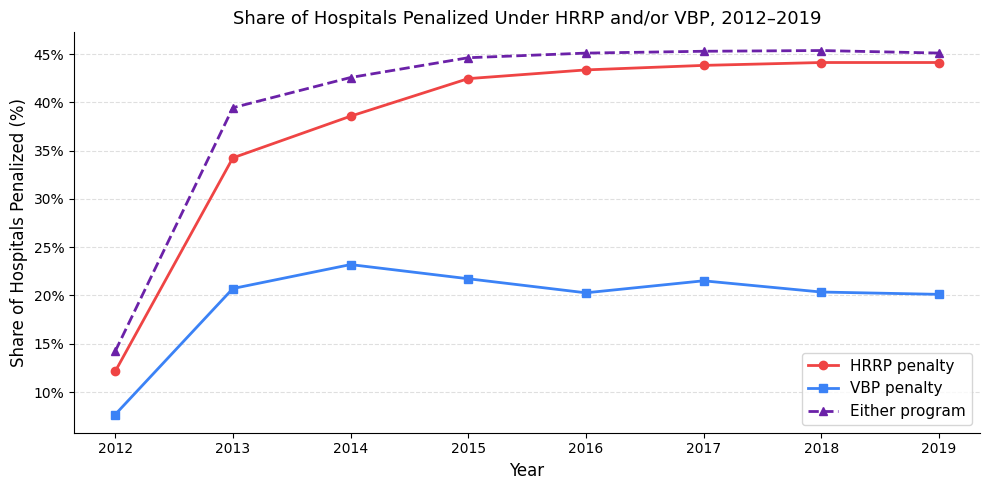

In [7]:
#Question 5

df1 = data[data['year'].between(2012, 2019)].copy()
 
 
df1['hrrp_penalized'] = df1['hrrp_payment'] > 0
df1['vbp_penalized']   = df1['hvbp_payment']  < 0
df1['any_penalized']   = df1['hrrp_penalized'] | df1['vbp_penalized']
 
#Share of penalized hospitals
def penalty_share(series):
    return series.sum() / series.notna().sum()
 
summary = (
    df1.groupby('year')
    .agg(
        hrrp_share  = ('hrrp_penalized', penalty_share),
        vbp_share   = ('vbp_penalized',  penalty_share),
        any_share   = ('any_penalized',  penalty_share),
        n_hospitals = ('provider_number', 'nunique'),
    )
    .reset_index()
)
 
print(summary.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.plot(summary['year'], summary['hrrp_share'] * 100,
        marker='o', color='#ef4444', linewidth=2, label='HRRP penalty')
ax.plot(summary['year'], summary['vbp_share']  * 100,
        marker='s', color='#3b82f6', linewidth=2, label='VBP penalty')
ax.plot(summary['year'], summary['any_share']  * 100,
        marker='^', color='#6b21a8', linewidth=2, linestyle='--',
        label='Either program')
 
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Share of Hospitals Penalized (%)', fontsize=12)
ax.set_title('Share of Hospitals Penalized Under HRRP and/or VBP, 2012–2019',
             fontsize=13)
ax.set_xticks(summary['year'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
plt.tight_layout()
plt.savefig('penalty_share_2012_2019.png', dpi=150, bbox_inches='tight')
plt.show()
 

In [8]:
# Data prep for IV

# Price
data['discount_factor'] = 1 - data['tot_discounts'] / data['tot_charges']
data['price_num']   = (
    (data['ip_charges'] + data['icu_charges'] + data['ancillary_charges'])
    * data['discount_factor']
    - data['tot_mcare_payment']
)
data['price_denom'] = data['tot_discharges'] - data['mcare_discharges']
data['price']       = data['price_num'] / data['price_denom']
 
data = data[data['price'] > 0]
def remove_outliers(g):
    lo, hi = g['price'].quantile([0.01, 0.99])
    return g[(g['price'] >= lo) & (g['price'] <= hi)]
data = data.groupby('year', group_keys=False).apply(remove_outliers)
 
# 2012 Penalty
data['net_penalty'] = data['hrrp_payment'].fillna(0) + data['hvbp_payment'].fillna(0)
 

price_2011 = (data[data['year'] == 2011]
              .groupby('provider_number')['price']
              .mean()
              .rename('price_2011'))
 
price_2014 = (data[data['year'] == 2014]
              .groupby('provider_number')['price']
              .mean()
              .rename('price_2014'))
 
# 2012 penalty
pen_2012 = (data[data['year'] == 2012]
            .groupby('provider_number')['net_penalty']
            .mean()
            .rename('net_penalty_2012'))
 
# Pre-2012 averages (2009-2011)
pre = data[data['year'].between(2009, 2011)]
mcare_pre = (pre.groupby('provider_number')['mcare_discharges']
               .mean()
               .rename('avg_mcare_pre'))
mcaid_pre  = (pre.groupby('provider_number')['mcaid_discharges']
               .mean()
               .rename('avg_mcaid_pre'))
beds_pre   = (pre.groupby('provider_number')['beds']
               .mean()
               .rename('avg_beds_pre'))
 
# Merge all into one cross-sectional dataframe
df_iv = (price_2011
         .to_frame()
         .join(price_2014, how='inner')
         .join(pen_2012,   how='inner')
         .join(mcare_pre,  how='inner')
         .join(mcaid_pre,  how='left')
         .join(beds_pre,   how='left')
         .dropna(subset=['price_2011', 'price_2014', 'net_penalty_2012',
                         'avg_mcare_pre']))
 
# Price change
df_iv['delta_price'] = df_iv['price_2014'] - df_iv['price_2011']
 
#  penalty indicator
df_iv['penalized'] = (df_iv['net_penalty_2012'] != 0).astype(int)
 


/tmp/ipykernel_3474859/2097234217.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('year', group_keys=False).apply(remove_outliers)


In [9]:
#Question 6
def ols_results(y, X_cols, df, label):
    """Run OLS and return a Series with coef/se for penalized."""
    X = sm.add_constant(df[X_cols])
    res = sm.OLS(y, X, missing='drop').fit(cov_type='HC1')
    return res
 
y = df_iv['delta_price']
 
ols1 = ols_results(y, ['penalized'], df_iv, 'Baseline')
ols2 = ols_results(y, ['penalized', 'avg_beds_pre'], df_iv, '+ Beds')
ols3 = ols_results(y, ['penalized', 'avg_beds_pre', 'avg_mcaid_pre'],
                   df_iv, '+ Beds + Medicaid')
 
def fmt_table_row(res, var='penalized'):
    c  = res.params[var]
    se = res.HC1_se[var]
    p  = res.pvalues[var]
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    return f"{c:>10.1f}{stars}  ({se:.1f})", res.nobs, round(res.rsquared, 3)
 
r1, n1, r2_1 = fmt_table_row(ols1)
r2, n2, r2_2 = fmt_table_row(ols2)
r3, n3, r2_3 = fmt_table_row(ols3)
 
print("\n" + "="*65)
print("Table 1: OLS Estimates — Effect of Net Penalty on Price Change")
print("="*65)
print(f"{'':30s} {'(1)':>12}  {'(2)':>12}  {'(3)':>12}")
print(f"{'Penalized (=1)':30s} {r1:>12}  {r2:>12}  {r3:>12}")
print(f"{'Bed size (pre-2012 avg)':30s} {'':>12}  {'Yes':>12}  {'Yes':>12}")
print(f"{'Medicaid disch. (pre-2012 avg)':30s} {'':>12}  {'':>12}  {'Yes':>12}")
print("-"*65)
print(f"{'N':30s} {n1:>12.0f}  {n2:>12.0f}  {n3:>12.0f}")
print(f"{'R-squared':30s} {r2_1:>12}  {r2_2:>12}  {r2_3:>12}")
print("="*65)
print("HC1 robust SE in parentheses. * p<0.10  ** p<0.05  *** p<0.01")


Table 1: OLS Estimates — Effect of Net Penalty on Price Change
                                        (1)           (2)           (3)
Penalized (=1)                      494.7***  (109.7)       489.2***  (109.6)       533.5***  (109.2)
Bed size (pre-2012 avg)                               Yes           Yes
Medicaid disch. (pre-2012 avg)                                      Yes
-----------------------------------------------------------------
N                                      2397          2397          2389
R-squared                             0.008          0.01         0.019
HC1 robust SE in parentheses. * p<0.10  ** p<0.05  *** p<0.01


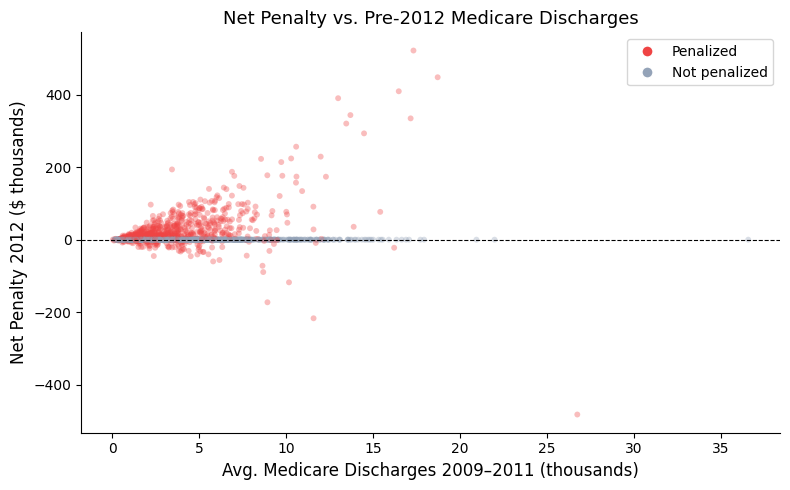

In [10]:
#Question 7
fig, ax = plt.subplots(figsize=(8, 5))
 
colors = df_iv['penalized'].map({1: '#ef4444', 0: '#94a3b8'})
ax.scatter(df_iv['avg_mcare_pre'] / 1_000, df_iv['net_penalty_2012'] / 1_000,
           c=colors, alpha=0.35, s=18, linewidths=0)
 
# Legend proxies
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ef4444',
           markersize=8, label='Penalized'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#94a3b8',
           markersize=8, label='Not penalized'),
]
ax.legend(handles=legend_els, fontsize=10)
 
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Avg. Medicare Discharges 2009–2011 (thousands)', fontsize=12)
ax.set_ylabel('Net Penalty 2012 ($ thousands)', fontsize=12)
ax.set_title('Net Penalty vs. Pre-2012 Medicare Discharges', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('q2_scatter_penalty_mcare.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
#Question 8

df_iv['avg_mcare_pre_k'] = df_iv['avg_mcare_pre'] / 1_000   # discharges in thousands
df_iv['net_penalty_k']   = df_iv['net_penalty_2012'] / 1_000 # penalty in $thousands
 
specs = [
    ('(1)', []),
    ('(2)', ['avg_beds_pre']),
    ('(3)', ['avg_beds_pre', 'avg_mcaid_pre']),
]
 
panels = {
    'Panel A: First Stage (Dep. var = Net Penalty, $000s)': 'net_penalty_k',
    'Panel B: Reduced Form (Dep. var = \u0394 Price)':       'delta_price',
}
 
def fs_rf_row(dep, instrument, controls, df):
    X   = sm.add_constant(df[[instrument] + controls])
    res = sm.OLS(df[dep], X, missing='drop').fit(cov_type='HC1')
    c   = res.params[instrument]
    se  = res.HC1_se[instrument]
    p   = res.pvalues[instrument]
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    return f"{c:>10.3f}{stars}  ({se:.3f})", res.nobs, round(res.rsquared, 3)
 
results = {
    title: [fs_rf_row(dep, 'avg_mcare_pre_k', controls, df_iv)
            for _, controls in specs]
    for title, dep in panels.items()
}
 
control_rows = [
    ('Bed size control',        [False, True,  True]),
    ('Medicaid disch. control', [False, False, True]),
]
 
W = 78
print("\n" + "="*W)
print("Table 2: First Stage and Reduced Form")
print("="*W)
print(f"{'':38s}" + "".join(f"  {label:>12}" for label, _ in specs))
 
for panel_title, rows in results.items():
    print(f"\n{panel_title}")
    print(f"{'Avg Medicare Disch. pre-2012 (000s)':38s}" +
          "".join(f"  {row[0]}" for row in rows))
    for label, flags in control_rows:
        print(f"  {label:36s}" +
              "".join(f"  {'Yes':>12}" if f else f"  {'':>12}" for f in flags))
    print("-"*W)
    print(f"{'N':38s}" + "".join(f"  {row[1]:>12.0f}" for row in rows))
    print(f"{'R-squared':38s}" + "".join(f"  {row[2]:>12}" for row in rows))
 
print("="*W)
print("HC1 robust SE in parentheses. * p<0.10  ** p<0.05  *** p<0.01")
print("Instrument: avg. Medicare discharges 2009-2011 (in thousands).")


Table 2: First Stage and Reduced Form
                                                 (1)           (2)           (3)

Panel A: First Stage (Dep. var = Net Penalty, $000s)
Avg Medicare Disch. pre-2012 (000s)          2.369***  (0.804)       2.376***  (0.803)       2.790***  (0.855)
  Bed size control                                             Yes           Yes
  Medicaid disch. control                                                    Yes
------------------------------------------------------------------------------
N                                               2397          2397          2389
R-squared                                      0.045         0.045         0.049

Panel B: Reduced Form (Dep. var = Δ Price)
Avg Medicare Disch. pre-2012 (000s)         22.097  (17.928)      18.326  (17.924)     -22.169  (23.172)
  Bed size control                                             Yes           Yes
  Medicaid disch. control                                                    Yes
-

In [12]:
#Question 9
def iv2sls_row(dep, endog, instrument, controls, df):
    sub = df[[dep, endog, instrument] + controls].dropna()
    y   = sub[dep]
    X   = sm.add_constant(sub[controls]) if controls else pd.DataFrame(
              np.ones(len(sub)), index=sub.index, columns=['const'])
    D   = sub[[endog]]
    Z   = sub[[instrument]]
    res = IV2SLS(y, X, D, Z).fit(cov_type='robust')
    c   = res.params[endog]
    se  = res.std_errors[endog]
    p   = res.pvalues[endog]
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    return f"{c:>10.1f}{stars}  ({se:.1f})", len(sub)
 
iv1, in1 = iv2sls_row('delta_price', 'penalized', 'avg_mcare_pre', [], df_iv)
iv2, in2 = iv2sls_row('delta_price', 'penalized', 'avg_mcare_pre',
                       ['avg_beds_pre'], df_iv)
iv3, in3 = iv2sls_row('delta_price', 'penalized', 'avg_mcare_pre',
                       ['avg_beds_pre', 'avg_mcaid_pre'], df_iv)
 
print("\n" + "="*65)
print("Table 3: IV (2SLS) Estimates — Effect of Net Penalty on Price Change")
print("="*65)
print(f"{'':30s} {'(1)':>12}  {'(2)':>12}  {'(3)':>12}")
print(f"{'Penalized (=1)':30s} {iv1}  {iv2}  {iv3}")
print(f"{'Bed size (pre-2012 avg)':30s} {'':>12}  {'Yes':>14}  {'Yes':>14}")
print(f"{'Medicaid disch. (pre-2012 avg)':30s} {'':>12}  {'':>14}  {'Yes':>14}")
print("-"*65)
print(f"{'N':30s} {in1:>12.0f}  {in2:>12.0f}  {in3:>12.0f}")
print("="*65)
print("Instrument: avg. Medicare discharges 2009-2011.")
print("Robust SE in parentheses. * p<0.10  ** p<0.05  *** p<0.01")


Table 3: IV (2SLS) Estimates — Effect of Net Penalty on Price Change
                                        (1)           (2)           (3)
Penalized (=1)                    -5546.0  (6642.4)     -4182.0  (5378.3)    -13841.4  (33911.4)
Bed size (pre-2012 avg)                                 Yes             Yes
Medicaid disch. (pre-2012 avg)                                          Yes
-----------------------------------------------------------------
N                                      2397          2397          2389
Instrument: avg. Medicare discharges 2009-2011.
Robust SE in parentheses. * p<0.10  ** p<0.05  *** p<0.01


In [13]:
#Question 10

